Aim: To build and evaluate a Decision Tree model for classification tasks and study the effect of tree depth and splitting criteria.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path = "/content/drive/MyDrive/mldataset/daily_weather.csv"
df = pd.read_csv(path)

df.head(5)

,number,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am,relative_humidity_9am,relative_humidity_3pm
0,0,918.060000,74.822000,271.100000,2.080354,295.400000,2.863283,0.0,0.0,42.420000,36.160000
1,1,917.347688,71.403843,101.935179,2.443009,140.471548,3.533324,0.0,0.0,24.328697,19.426597
2,2,923.040000,60.638000,51.000000,17.067852,63.700000,22.100967,0.0,20.0,8.900000,14.460000
3,3,920.502751,70.138895,198.832133,4.337363,211.203341,5.190045,0.0,0.0,12.189102,12.742547
4,4,921.160000,44.294000,277.800000,1.856660,136.500000,2.863283,8.9,14730.0,92.410000,76.740000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   number                  1095 non-null   int64  
 1   air_pressure_9am        1092 non-null   float64
 2   air_temp_9am            1090 non-null   float64
 3   avg_wind_direction_9am  1091 non-null   float64
 4   avg_wind_speed_9am      1092 non-null   float64
 5   max_wind_direction_9am  1092 non-null   float64
 6   max_wind_speed_9am      1091 non-null   float64
 7   rain_accumulation_9am   1089 non-null   float64
 8   rain_duration_9am       1092 non-null   float64
 9   relative_humidity_9am   1095 non-null   float64
 10  relative_humidity_3pm   1095 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 94.2 KB


In [6]:
df.shape

(1095, 11)

In [7]:
df.describe()


,number,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am,relative_humidity_9am,relative_humidity_3pm
count,1095.000000,1092.000000,1090.000000,1091.000000,1092.000000,1092.000000,1091.000000,1089.000000,1092.000000,1095.000000,1095.000000
mean,547.000000,918.882551,64.933001,142.235511,5.508284,148.953518,7.019514,0.203079,294.108052,34.241402,35.344727
std,316.243577,3.184161,11.175514,69.137859,4.552813,67.238013,5.598209,1.593952,1598.078779,25.472067,22.524079
min,0.000000,907.990000,36.752000,15.500000,0.693451,28.900000,1.185578,0.000000,0.000000,6.090000,5.300000
25%,273.500000,916.550000,57.281000,65.972506,2.248768,76.553003,3.067477,0.000000,0.000000,15.092243,17.395000
50%,547.000000,918.921045,65.715479,166.000000,3.871333,177.300000,4.943637,0.000000,0.000000,23.179259,24.380000
75%,820.500000,921.160073,73.450974,191.000000,7.337163,201.233153,8.947760,0.000000,0.000000,45.400000,52.060000
max,1094.000000,929.320000,98.906000,343.400000,23.554978,312.200000,29.840780,24.020000,17704.000000,92.620000,92.250000


In [8]:
del df['number']

In [9]:
df = df.dropna()

In [10]:
df['high_humidity_label'] = (df['relative_humidity_9am'] > 25).astype(int)

In [11]:
X = df.drop('high_humidity_label', axis=1)
y = df['high_humidity_label']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [13]:
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

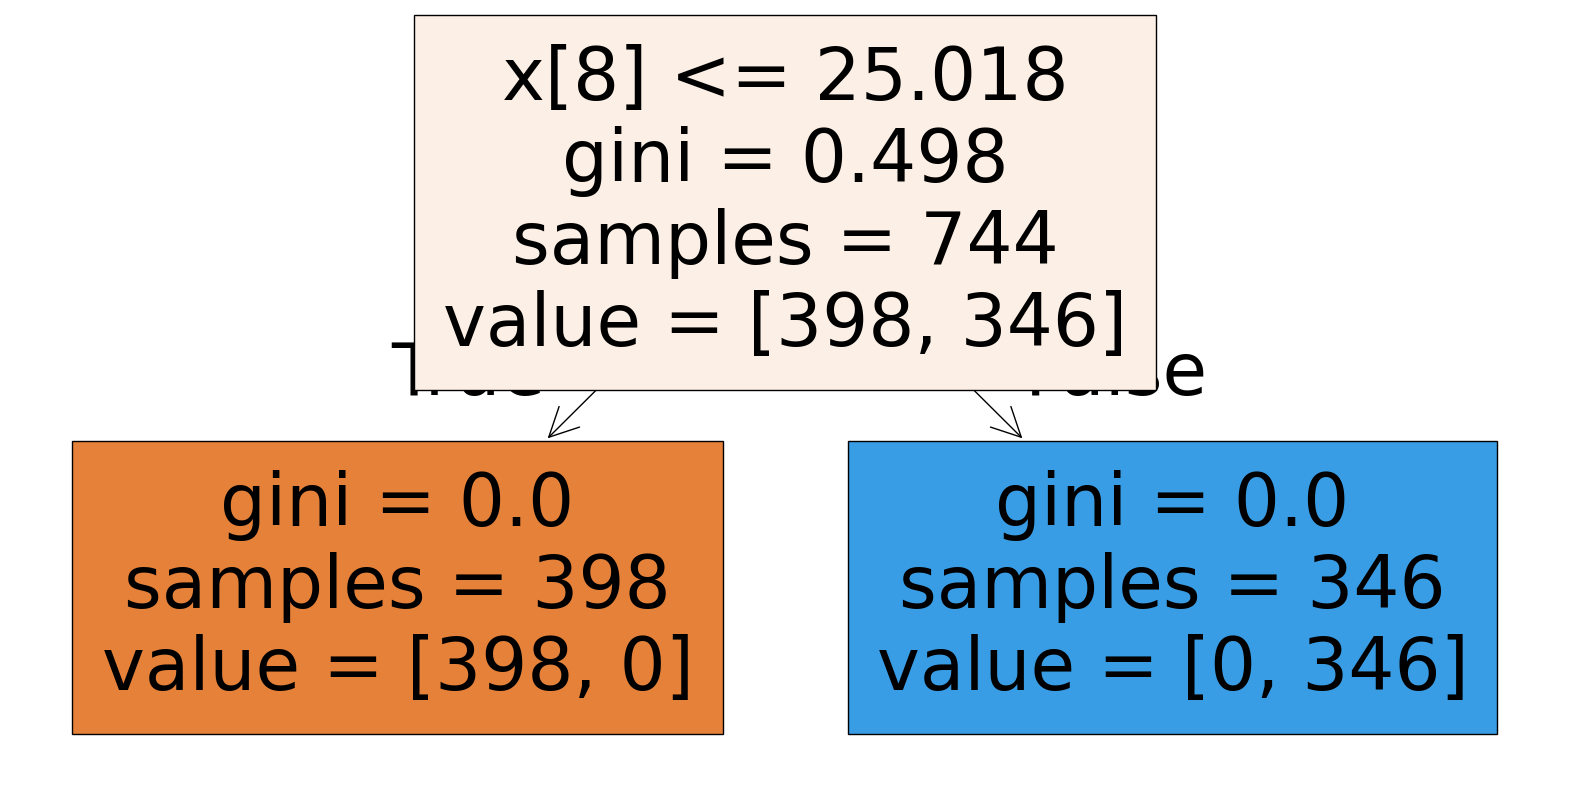

In [14]:
plt.figure(figsize=(20,10))
tree.plot_tree(model, filled=True)
plt.show()

In [15]:
y_pred = model.predict(X_test)
print(y_pred)

[0 1 1 1 1 1 1 1 1 0 1 1 0 1 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 0 1 1 0 1 1 1
 0 1 0 1 0 1 1 1 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 1 1
 1 1 0 0 1 1 1 0 1 1 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 1 1 1 0
 1 0 1 0 1 0 0 0 1 0 1 0 1 0 1 0 0 0 1 1 1 0 1 0 0 1 1 0 0 1 1 0 0 1 1 1 1
 0 1 0 0 1 0 1 0 0 0 1 1 0 0 0 1 1 1 0 0 0 1 1 0 0 1 0 0 0 1 1 1 1 1 0 0 0
 0 0 1 0 1 1 1 1 0 1 0 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 0 1 1 1 1 0 0 0 0 0 0
 1 0 0 0 0 1 0 1 0 0 1 1 1 0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0 1
 0 1 1 0 1 0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 1 0 0 1 1 0 1 1 0 1 0 1 0 1 0 0 1
 1 1 1 0 0 0 0 1 0 1 1 1 1 0 1 0 1 0 1 0 1 1 0 0]


In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       167
           1       1.00      1.00      1.00       153

    accuracy                           1.00       320
   macro avg       1.00      1.00      1.00       320
weighted avg       1.00      1.00      1.00       320

